# Import Libraries

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Create Dataset

In [61]:
np.random.seed(42) # seed is used to reproduce the same random numbers for consistency. 
data={
    'product_id': np.arange(1, 21),
    'product_name': [f'Product {i}' for i in range(1, 21)],
    'category': np.random.choice(['Electronics', 'Clothing', 'Home Appliances', 'sports'],20),
    'units_sold': np.random.poisson(lam=20, size=20), #portion distribution for units sold
    'sale_date': pd.date_range(start='2023-01-01', periods=20, freq='D'),
}

sales_data=pd.DataFrame(data)

print("Sales Data:")
print(sales_data)

Sales Data:
    product_id product_name         category  units_sold  sale_date
0            1    Product 1  Home Appliances          25 2023-01-01
1            2    Product 2           sports          15 2023-01-02
2            3    Product 3      Electronics          17 2023-01-03
3            4    Product 4  Home Appliances          19 2023-01-04
4            5    Product 5  Home Appliances          21 2023-01-05
5            6    Product 6           sports          17 2023-01-06
6            7    Product 7      Electronics          19 2023-01-07
7            8    Product 8      Electronics          16 2023-01-08
8            9    Product 9  Home Appliances          21 2023-01-09
9           10   Product 10         Clothing          21 2023-01-10
10          11   Product 11  Home Appliances          17 2023-01-11
11          12   Product 12  Home Appliances          22 2023-01-12
12          13   Product 13  Home Appliances          14 2023-01-13
13          14   Product 14  Home Ap

# Export the Dataset

In [62]:
sales_data.to_csv('sales_data.csv', index=False)

In [63]:
import os
os.getcwd()

'd:\\fsds\\projects\\code'

# Descriptive Statistics

In [64]:
descriptive_stats= sales_data['units_sold'].describe()

print('\n Descriptive stats for number of units sold:')
print(descriptive_stats)

mean_sales=sales_data['units_sold'].mean()
median_sales=sales_data['units_sold'].median()
mode_sales=sales_data['units_sold'].mode()[0]
variance_sales=sales_data['units_sold'].var()
standard_deviation_sales=sales_data['units_sold'].std()

category_stats=sales_data.groupby('category')['units_sold'].agg(['sum', 'mean', 'std']).reset_index()
category_stats.columns=['Category', 'Total Units Sold', 'Average Units Sold', 'Standard Deviation']

print('\nStatistical Analysis:')
print(f'Mean of Units Sold:{mean_sales}')
print(f'Median of Units Sold:{median_sales}')
print(f'Mode of Units Sold:{mode_sales}')
print(f'Variance of Units Sold:{variance_sales}')
print(f'Standard Deviation of Units Sold:{standard_deviation_sales}')
print('\nCategory-wise Statistics:')
print(category_stats)


 Descriptive stats for number of units sold:
count    20.000000
mean     18.800000
std       3.302312
min      13.000000
25%      17.000000
50%      18.500000
75%      21.000000
max      25.000000
Name: units_sold, dtype: float64

Statistical Analysis:
Mean of Units Sold:18.8
Median of Units Sold:18.5
Mode of Units Sold:17
Variance of Units Sold:10.905263157894737
Standard Deviation of Units Sold:3.302311789927586

Category-wise Statistics:
          Category  Total Units Sold  Average Units Sold  Standard Deviation
0         Clothing                21           21.000000                 NaN
1      Electronics                73           18.250000            2.217356
2  Home Appliances               181           20.111111            3.723051
3           sports               101           16.833333            2.714160


# Inferential Statistics


In [65]:
confidence_level = 0.95
degrees_freedom=len(sales_data['units_sold'])-1
sample_mean=mean_sales
sample_standard_error=standard_deviation_sales/np.sqrt(len(sales_data['units_sold']))

t_score = stats.t.ppf((1+confidence_level)/2, degrees_freedom)
margin_of_error = t_score*sample_standard_error

confidence_interval = (sample_mean - margin_of_error, sample_mean + margin_of_error)
print('\nConfidence Interval for Mean Units Sold:')
print(confidence_interval)


Confidence Interval for Mean Units Sold:
(17.254470507823573, 20.34552949217643)


In [66]:
confidence_level = 0.99
degrees_freedom=len(sales_data['units_sold'])-1
sample_mean=mean_sales
sample_standard_error=standard_deviation_sales/np.sqrt(len(sales_data['units_sold']))

t_score = stats.t.ppf((1+confidence_level)/2, degrees_freedom)
margin_of_error = t_score*sample_standard_error

confidence_interval = (sample_mean - margin_of_error, sample_mean + margin_of_error)
print('\nConfidence Interval for Mean Units Sold:')
print(confidence_interval)


Confidence Interval for Mean Units Sold:
(16.687430485978535, 20.912569514021467)


# Hypothesis Testing

In [67]:
t_statistics, p_value=stats.ttest_1samp(sales_data['units_sold'],20)

print('\nHypothesis Testing(t-test):')
print(f'T-statistics: {t_statistics}, P-value: {p_value}')

if p_value < 0.05:
    print('Reject the null hypothesis: The mean units sold is significantly different from 20.')
else:
    print('Fail to reject the null hypothesis: The mean units sold is not significantly different from 20.')


Hypothesis Testing(t-test):
T-statistics: -1.6250928099424466, P-value: 0.12061572226781002
Fail to reject the null hypothesis: The mean units sold is not significantly different from 20.


# Visualizations 

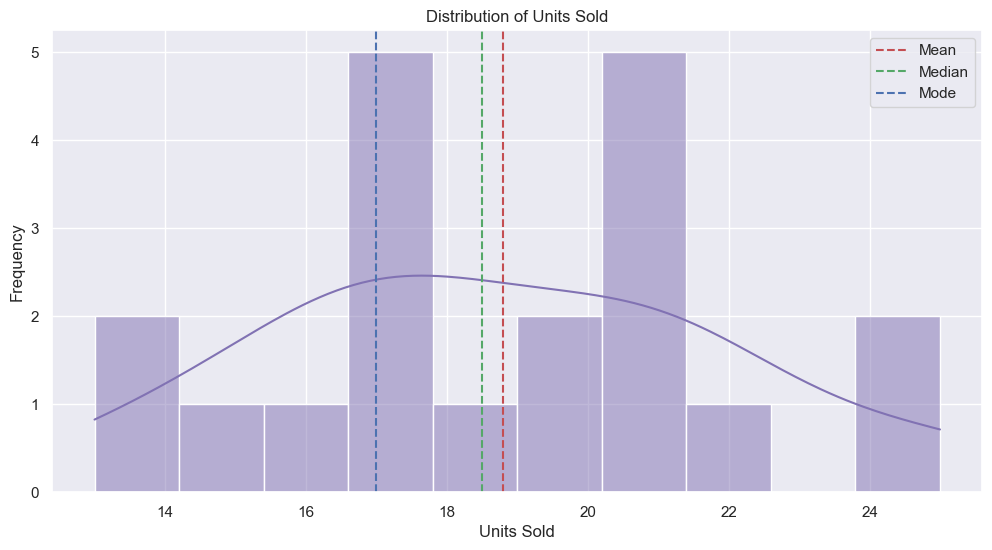

C:\Users\bhara\AppData\Local\Temp\ipykernel_28908\2525446413.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='category', y='units_sold', data=sales_data, palette='Set2')


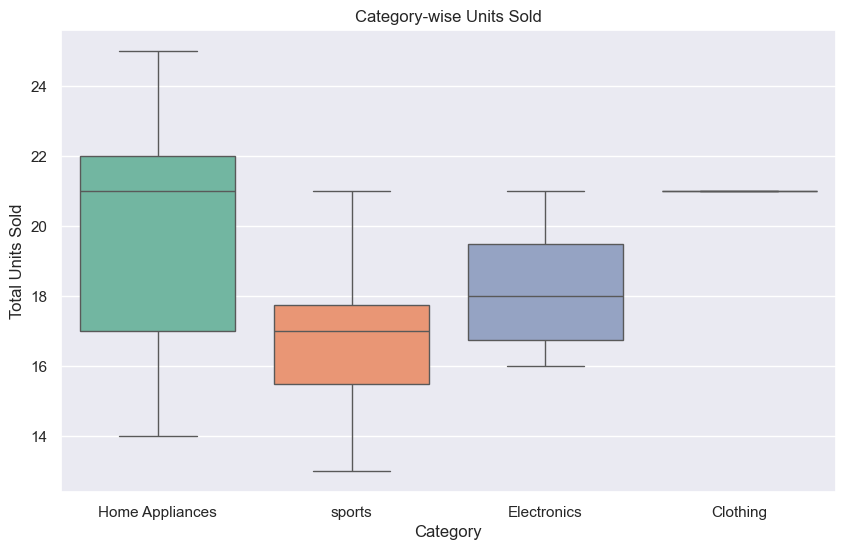

C:\Users\bhara\AppData\Local\Temp\ipykernel_28908\2525446413.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='category', y='units_sold', data=sales_data, palette='Set1')


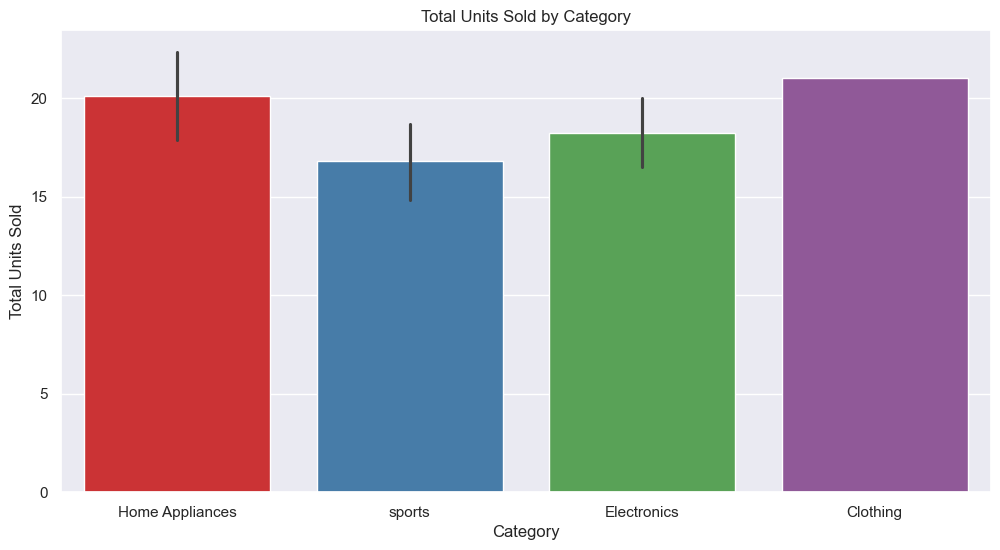

In [68]:
sns.set(style='darkgrid')

plt.figure(figsize=(12, 6))
sns.histplot(sales_data['units_sold'], bins=10, kde=True, color='m')
plt.title('Distribution of Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')
plt.axvline(mean_sales, color='r', linestyle='--', label='Mean')
plt.axvline(median_sales, color='g', linestyle='--', label='Median')
plt.axvline(mode_sales, color='b', linestyle='--', label='Mode')
plt.legend()
plt.show()

#Box plot for category-wise total units sold
plt.figure(figsize=(10, 6))
sns.boxplot(x='category', y='units_sold', data=sales_data, palette='Set2')
plt.title('Category-wise Units Sold')
plt.xlabel('Category')
plt.ylabel('Total Units Sold')
plt.show()

# Bar plot total no of units sold category-wise
plt.figure(figsize=(12, 6))
sns.barplot(x='category', y='units_sold', data=sales_data, palette='Set1')
plt.title('Total Units Sold by Category')
plt.xlabel('Category')
plt.ylabel('Total Units Sold')
plt.show()